In [1]:
import pandas as pd


df = pd.read_json(
    "../data/processed/Movies_Features.json"
)

print(df.shape)
print(df.head())


features = [
    "runtime",
    "budget",
    "revenue",
    "popularity",
    "vote_average",
    "num_genres",
    "num_keywords",
    "release_year"
]

X = df[features]
print(X.isnull().sum())
X = X.fillna(0)

print("Clustering data shape:", X.shape)

(2740, 20)
   movie_id                      title  \
0    969681  Spider-Man: Brand New Day   
1   1423191              Resident Evil   
2   1101383      The End of Oak Street   
3   1204680            Coyote vs. Acme   
4   1368337                The Odyssey   

                                            overview  release_date  runtime  \
0  Fighting crime full-time as Spider-Man in a wo...     1785283.0      145   
1  Medical courier Bryan unwittingly finds himsel...     1789516.0       95   
2  After a mysterious cosmic event rips Oak Stree...     1786492.0      100   
3  After Acme products fail him one too many time...     1786924.0      103   
4  Odysseus, the legendary King of Ithaca, embark...     1784073.0      173   

  original_language                                genres  \
0                en  [Science Fiction, Action, Adventure]   
1                en  [Horror, Science Fiction, Adventure]   
2                en  [Science Fiction, Mystery, Thriller]   
3                

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original data:")
print(X.head())

print("\nScaled data:")
print(X_scaled[:5])

Original data:
   runtime     budget     revenue  popularity  vote_average  num_genres  \
0      145  225000000  2495683000         687             7           3   
1       95   75000000   196476247         407             7           3   
2      100   80000000   120363694         392             7           3   
3      103   72000000    88043208         355             7           3   
4      173  250000000  1751248000         366             8           3   

   num_keywords  release_year  
0            19        1970.0  
1            20        1970.0  
2            17        1970.0  
3            13        1970.0  
4            18        1970.0  

Scaled data:
[[ 1.32432971e+00  2.78693490e+00  8.51113006e+00  2.43655671e+01
   6.02048896e-01  2.79699061e-01  4.67787328e-01  1.97477326e-02]
 [-6.35732626e-01  3.79343333e-01  5.83169236e-02  1.41371487e+01
   6.02048896e-01  2.79699061e-01  5.80785414e-01  1.97477326e-02]
 [-4.39726393e-01  4.59596385e-01 -2.21503578e-01  1.35891978e

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 9)

inertia_values = []
silhouette_values = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(
        X_scaled
    )

    inertia = kmeans.inertia_

    silhouette = silhouette_score(
        X_scaled,
        clusters
    )

    inertia_values.append(inertia)
    silhouette_values.append(silhouette)

    print(
        "K:", k,
        "| Inertia:", inertia,
        "| Silhouette:", silhouette
    )

results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette": silhouette_values
})

print(results)

K: 2 | Inertia: 18379.728381662586 | Silhouette: 0.2848374330081996
K: 3 | Inertia: 15609.129874122666 | Silhouette: 0.2952171068819478
K: 4 | Inertia: 13660.720225492458 | Silhouette: 0.16311388614652833
K: 5 | Inertia: 12115.924570218383 | Silhouette: 0.1719788719209212
K: 6 | Inertia: 10790.201827072844 | Silhouette: 0.1750829535233846
K: 7 | Inertia: 9690.68768767713 | Silhouette: 0.1866885060273051
K: 8 | Inertia: 9004.69480573135 | Silhouette: 0.18029394979911675
   K       Inertia  Silhouette
0  2  18379.728382    0.284837
1  3  15609.129874    0.295217
2  4  13660.720225    0.163114
3  5  12115.924570    0.171979
4  6  10790.201827    0.175083
5  7   9690.687688    0.186689
6  8   9004.694806    0.180294


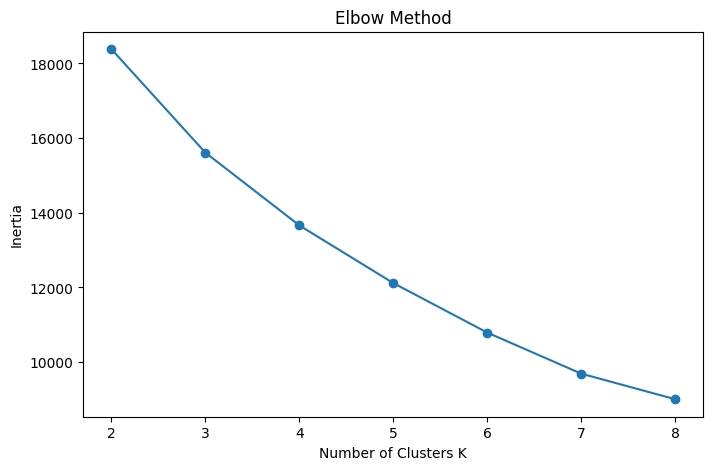

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters K")
plt.ylabel("Inertia")

plt.show()

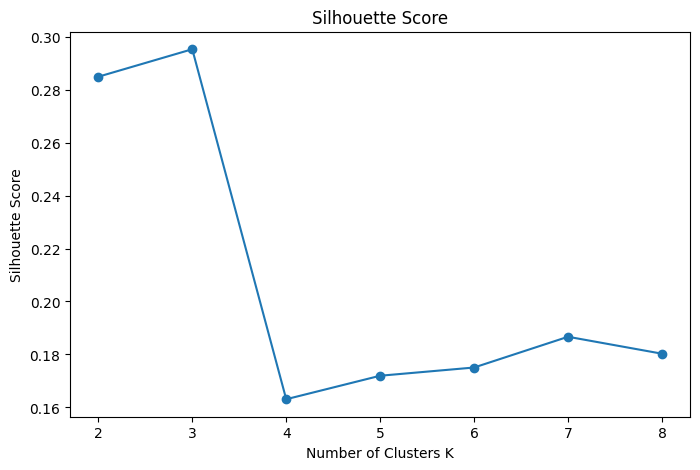

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_values,
    marker="o"
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")

plt.show()

In [7]:
best_index = silhouette_values.index(
    max(silhouette_values)
)

best_k = list(k_values)[best_index]

print("Best K:", best_k)
print(
    "Best Silhouette Score:",
    max(silhouette_values)
)

Best K: 3
Best Silhouette Score: 0.2952171068819478


In [9]:

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)


clusters = final_kmeans.fit_predict(
    X_scaled
)

df["cluster"] = clusters


print(
    df[
        [
            "title",
            "cluster"
        ]
    ]
)

                           title  cluster
0      Spider-Man: Brand New Day        0
1                  Resident Evil        0
2          The End of Oak Street        0
3                Coyote vs. Acme        0
4                    The Odyssey        0
...                          ...      ...
2735             Ghost Elephants        1
2736                   Eddington        1
2737  The Taking of Pelham 1 2 3        1
2738                 The Wolfman        1
2739  Ace Ventura: Pet Detective        1

[2740 rows x 2 columns]
